In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from modules.finance.exploration import *
from modules.index.visualisation import plot_indices_with_returns

plt.rcParams.update({"font.size": 14})
pd.set_option("display.max_columns", None)

In [2]:
# Configuration
DATA_DIR = "./data/"
OUTPUT_DIR = "./data/fm_prelim/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Files
FINANCIAL_PANEL_FILE = DATA_DIR + "financial_returns_and_controls.parquet"
EPI_DATA_FILE = DATA_DIR + "epi_data_all_lownull.json"

# Parameters
ROLLING_WINDOW = 14
MAX_LAG = 10
IC = 'aic'
ALPHA = 0.05
CORRECTION_METHOD = 'fdr_bh'

print("✓ Configuration complete")

✓ Configuration complete


## Load Data

In [3]:
# Load data
df_returns = pd.read_parquet(FINANCIAL_PANEL_FILE)
df_epi = pd.read_json(EPI_DATA_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

df = df_returns.join(df_epi, how='left')
df[df_epi.columns] = df[df_epi.columns].fillna(0)

print(f"Data loaded: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Data loaded: (104, 152)
Date range: 2025-01-07 00:00:00 to 2025-05-30 00:00:00


In [4]:
# Find Surprise variants
surprise_variants = find_index_variants(df.columns, 'surprise')
ASSET_COLS = [
    'r_btc', 'r_gold', 'r_spx', 
    'r_spx_auto', 'r_spx_oilgas', 'r_spx_mach', 'r_spx_elec', 
    'r_aapl'
]
ASSET_COLS = [c for c in ASSET_COLS if c in df.columns]

print(f"\nSurprise variants found: {len(surprise_variants)}")
for i, var in enumerate(surprise_variants, 1):
    print(f"  {i}. {var}")
print(f"\nAssets: {ASSET_COLS}")


Surprise variants found: 4
  1. surprise
  2. surprise_engweighted
  3. surprise_topicweighted
  4. surprise_engweighted_topicweighted

Assets: ['r_btc', 'r_gold', 'r_spx', 'r_spx_auto', 'r_spx_oilgas', 'r_spx_mach', 'r_spx_elec', 'r_aapl']


## Descriptive Statistics


Descriptive Statistics

Surprise Variants


,count,mean,std,min,25%,50%,75%,max,skew,kurt,missing_pct,zero_pct
surprise,104.0,0.045963,0.010332,0.023245,0.038349,0.045261,0.050396,0.084056,1.170668,2.329502,0.0,0.0
surprise_engweighted,104.0,0.046030,0.010009,0.023245,0.038531,0.045023,0.050311,0.081319,1.098369,2.217565,0.0,0.0
surprise_engweighted_topicweighted,104.0,0.045294,0.012421,0.019221,0.036938,0.044272,0.050420,0.093958,1.396333,3.536964,0.0,0.0
surprise_topicweighted,104.0,0.045373,0.012728,0.019560,0.036699,0.044586,0.050687,0.097101,1.480129,3.776359,0.0,0.0



Correlation between variants:


,surprise,surprise_engweighted,surprise_topicweighted,surprise_engweighted_topicweighted
surprise,1.000000,0.991536,0.931463,0.922159
surprise_engweighted,0.991536,1.000000,0.922399,0.926971
surprise_topicweighted,0.931463,0.922399,1.000000,0.992632
surprise_engweighted_topicweighted,0.922159,0.926971,0.992632,1.000000


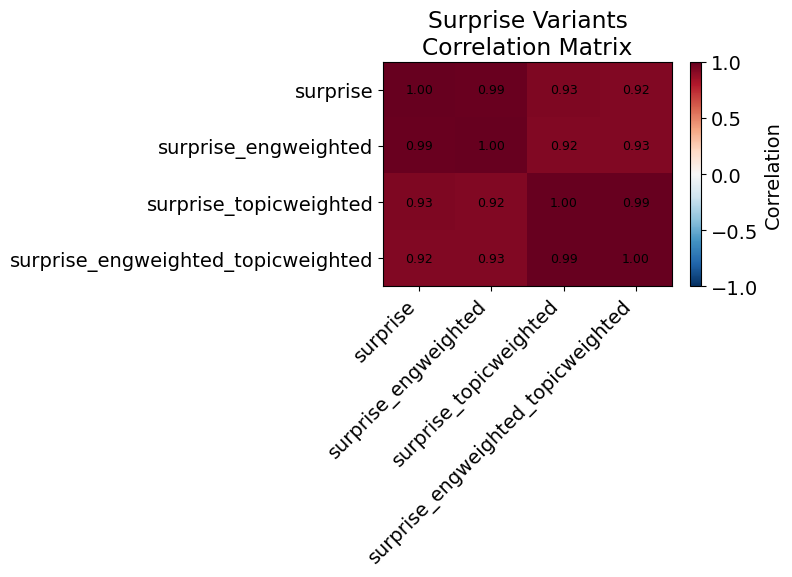

In [5]:
print("\n" + "="*70)
print("Descriptive Statistics")
print("="*70)
stats = compare_index_variants_descriptive(df, surprise_variants, 'Surprise Variants')

## Time Series Visualization


Time Series Visualization


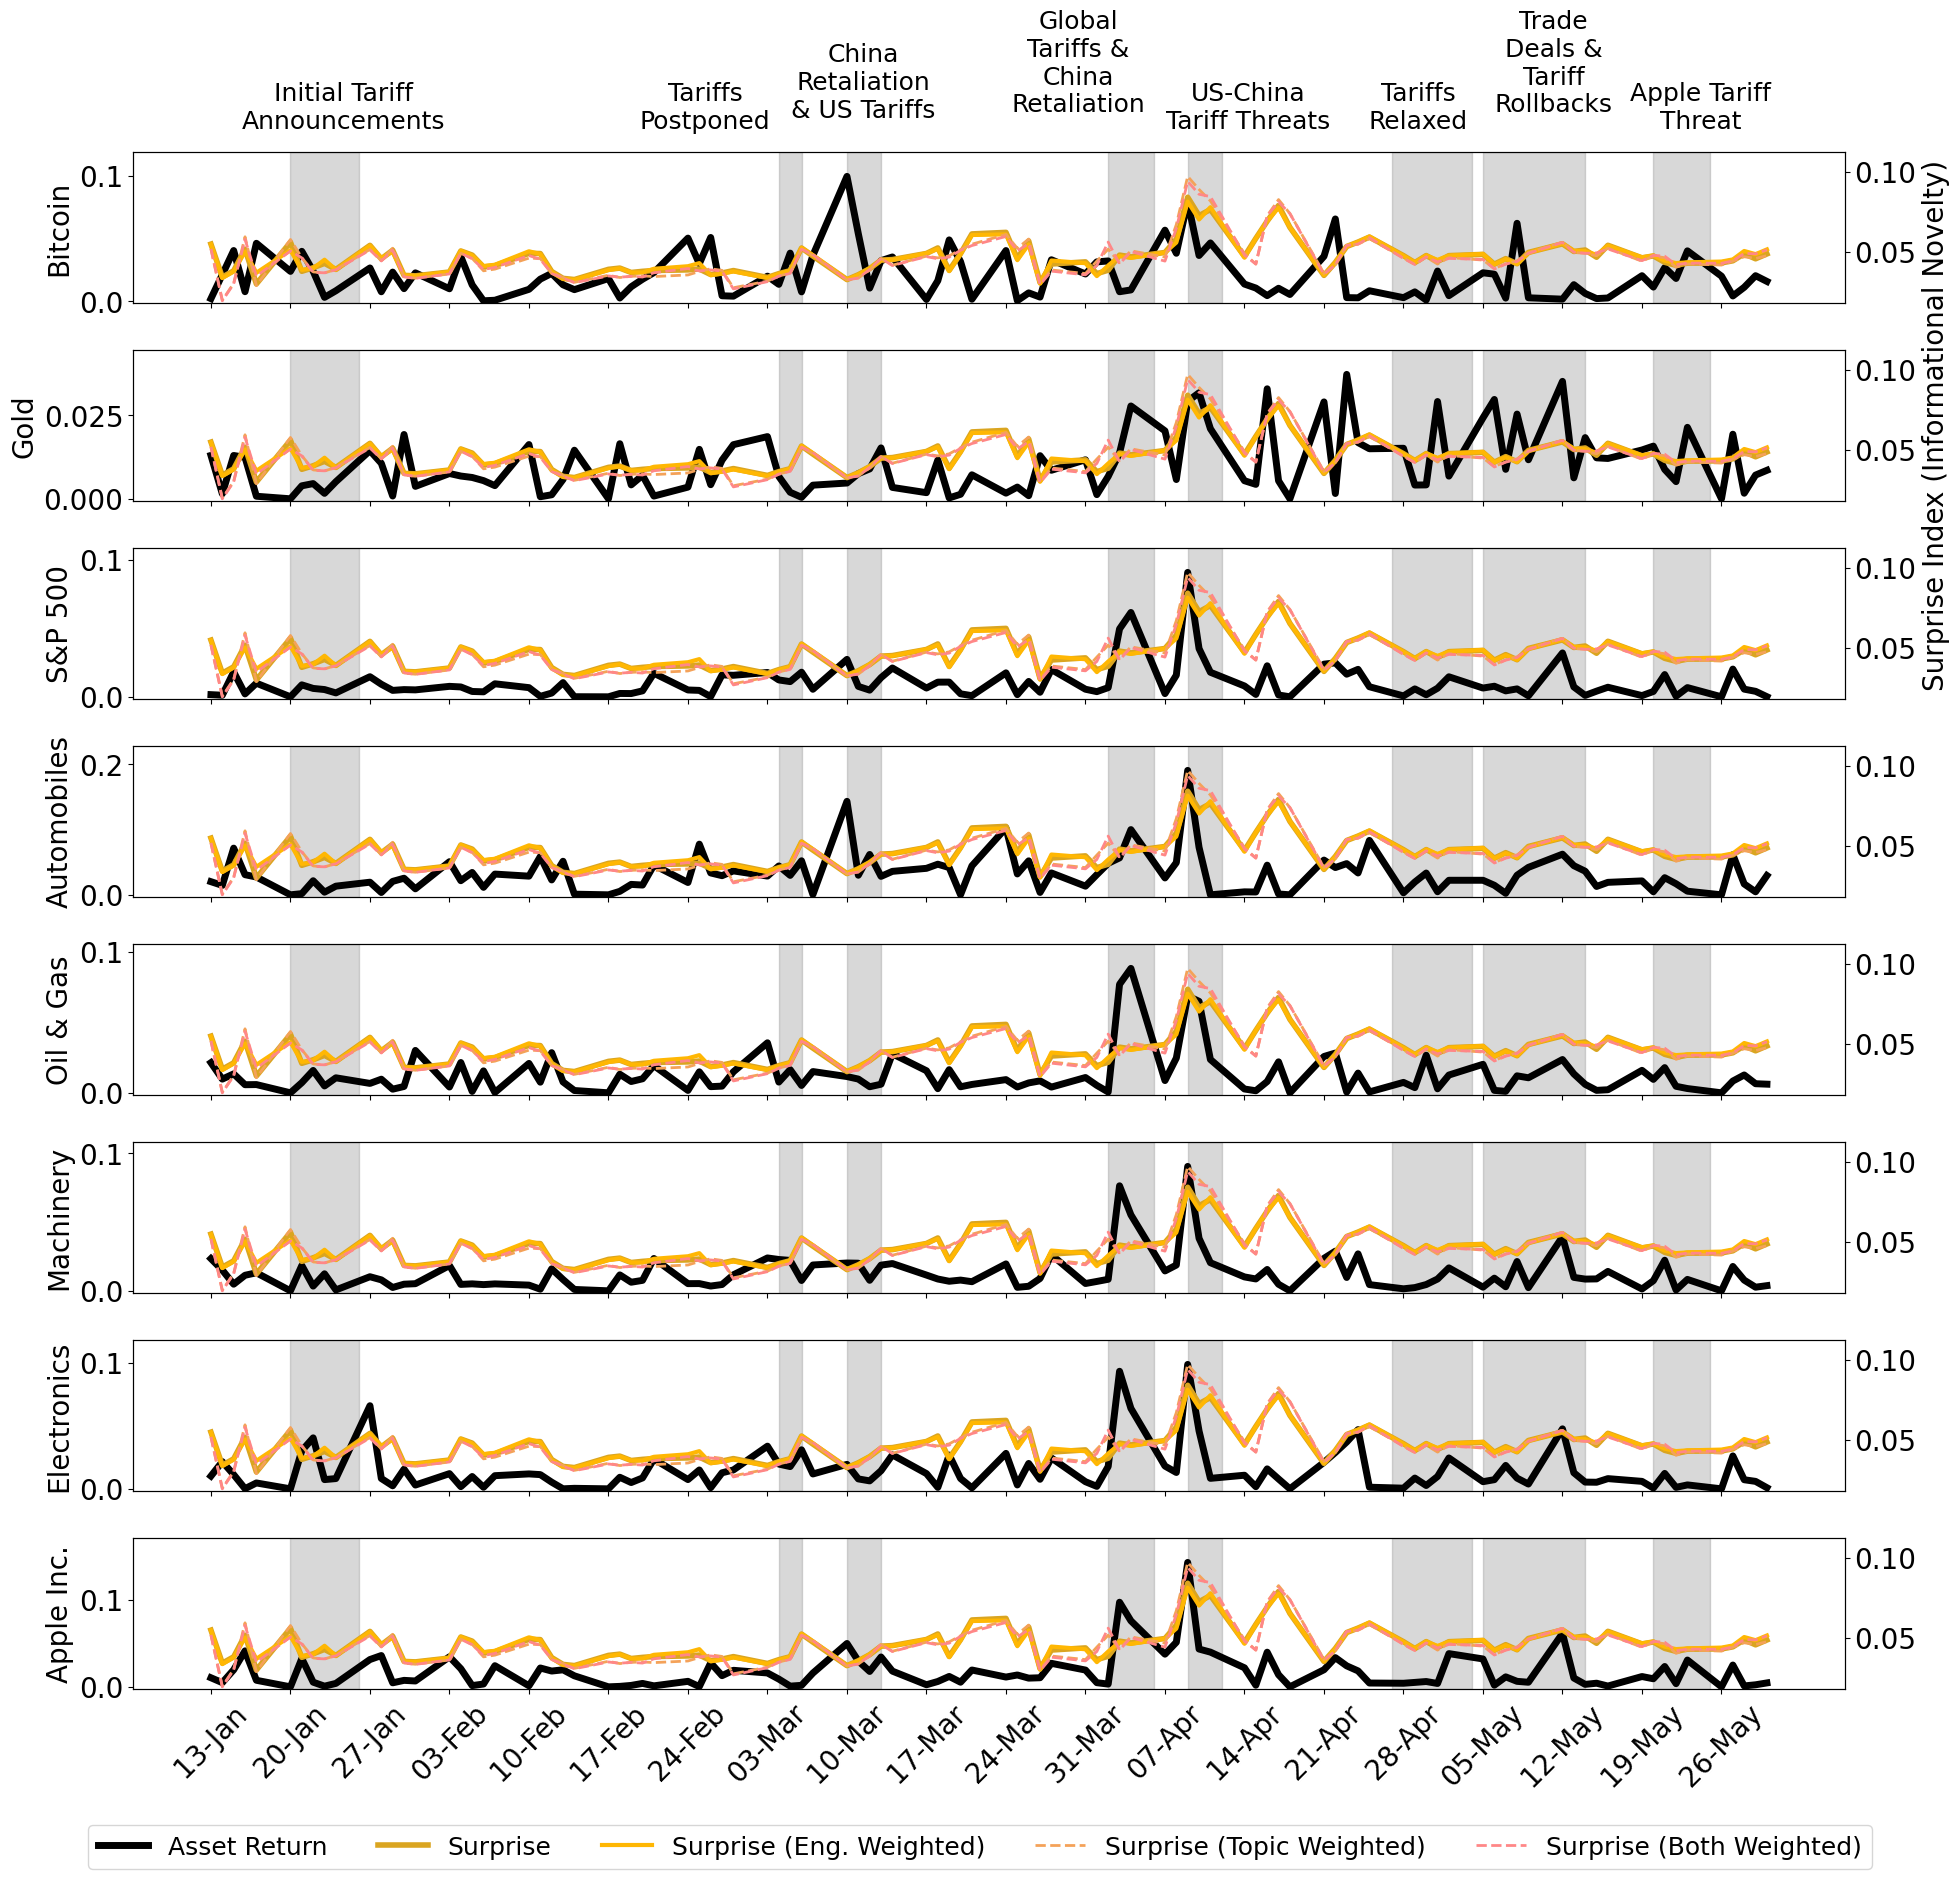

In [6]:
print("\n" + "="*70)
print("Time Series Visualization")
print("="*70)
plot_indices_with_returns(df, index_type='surprise', include_variants=surprise_variants, add_events=True)

## Rolling Correlations with Assets


Rolling Correlations with Assets


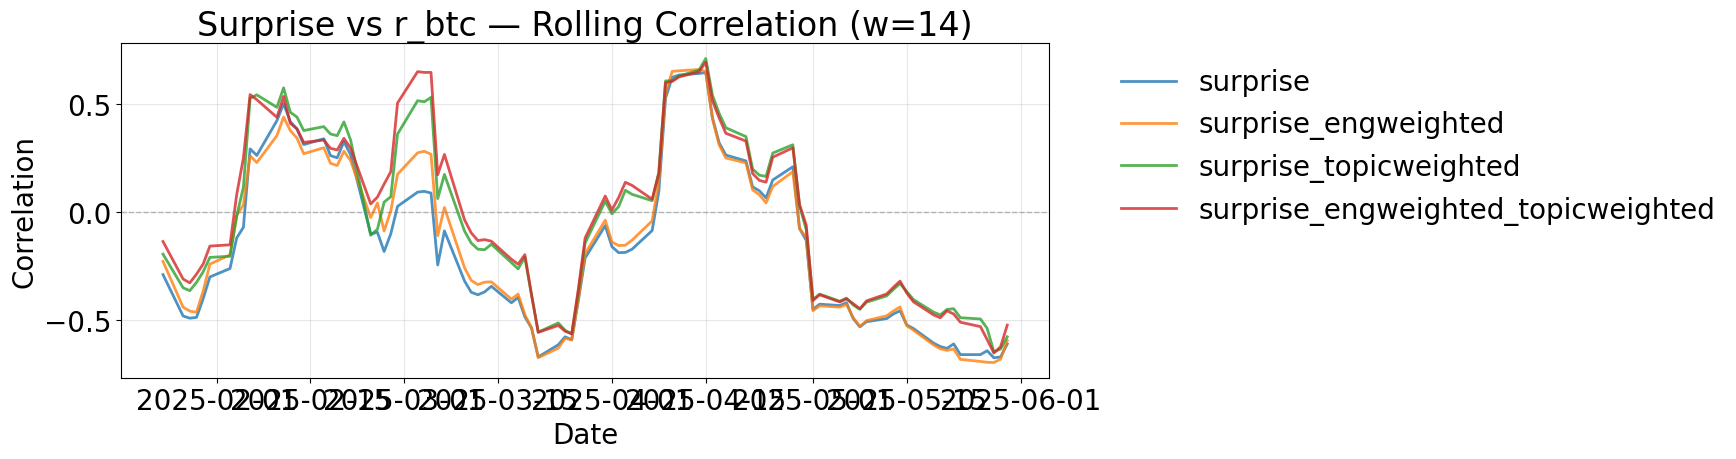

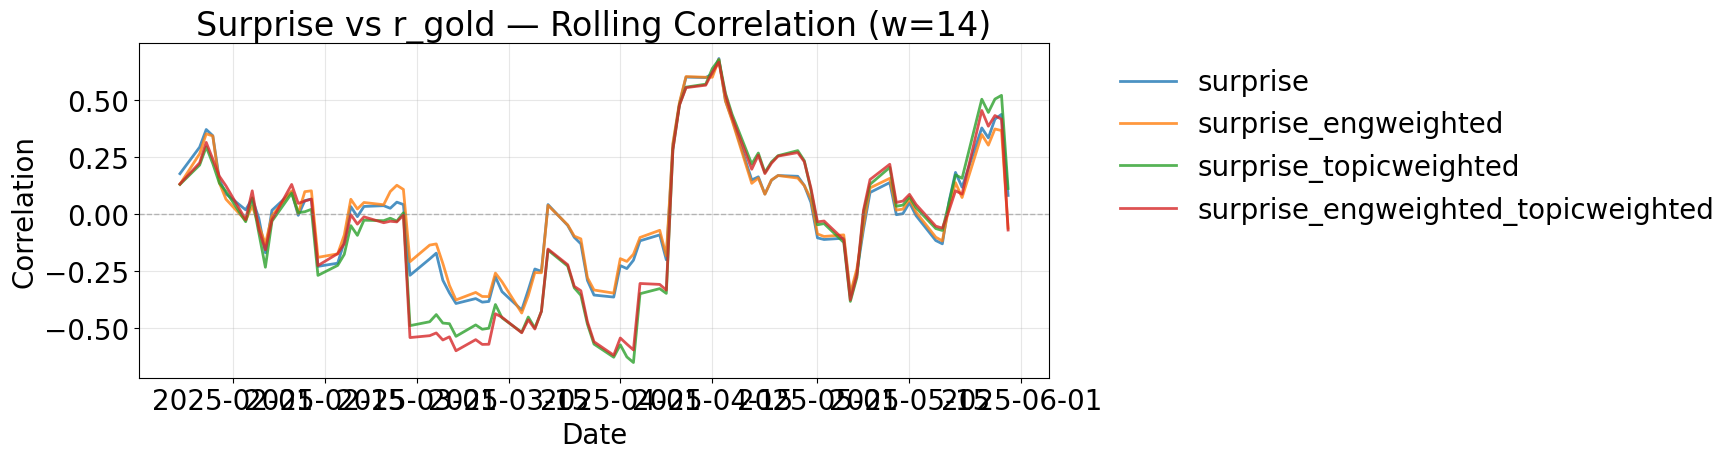

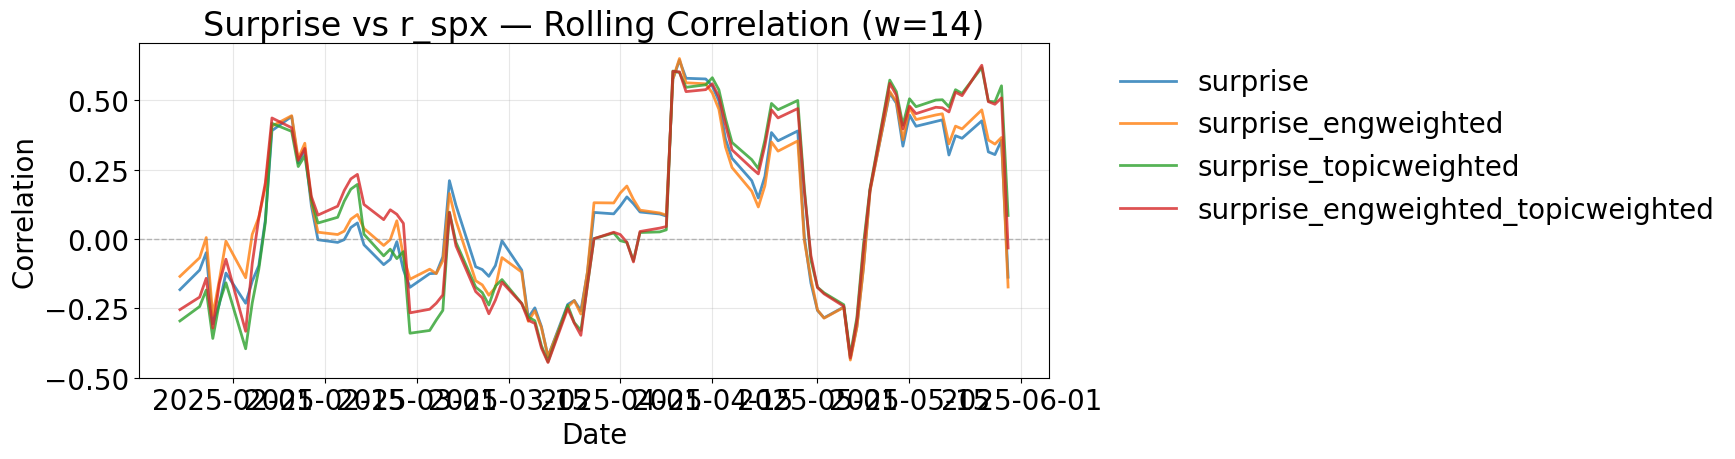

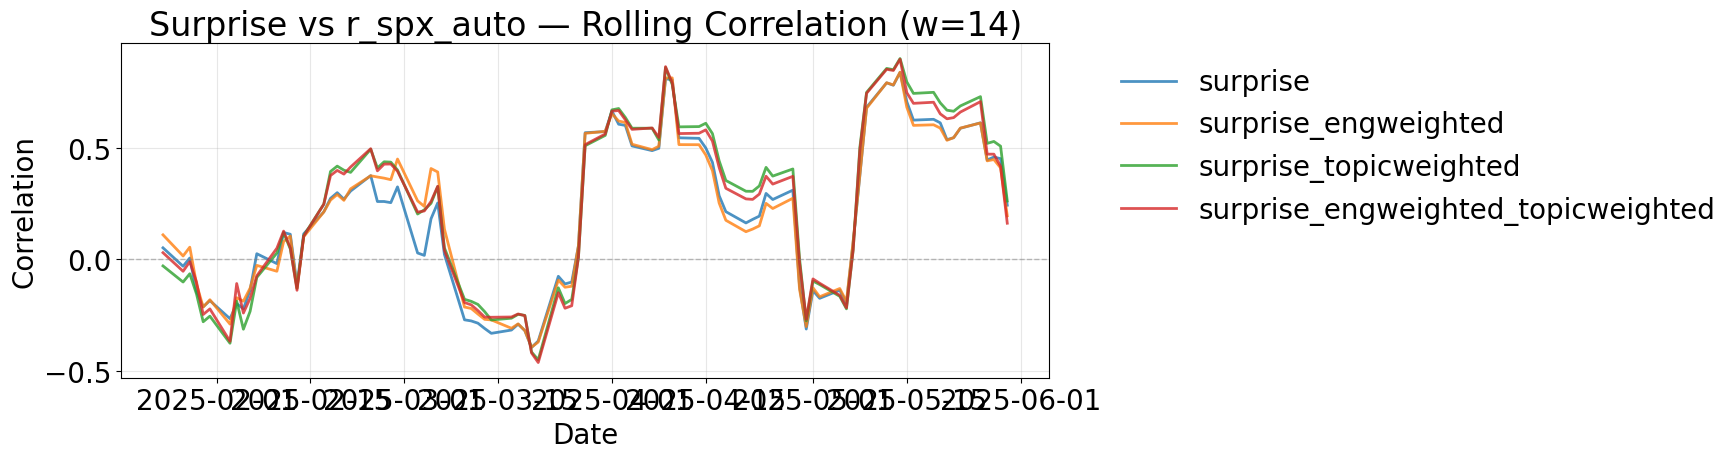

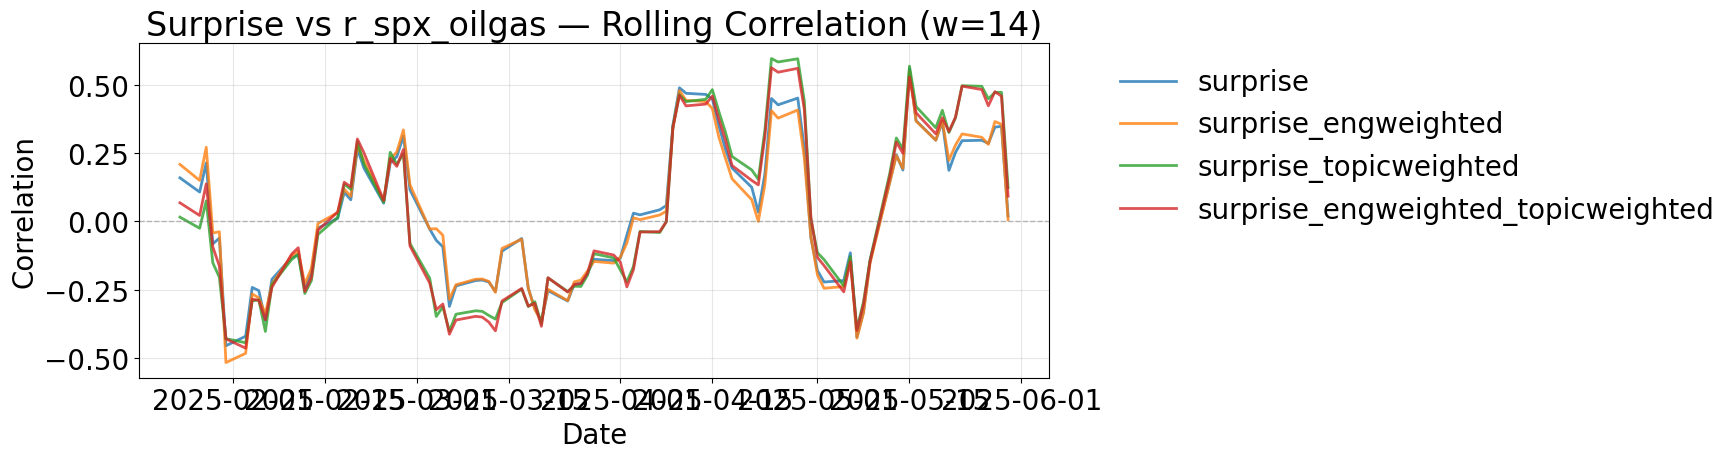

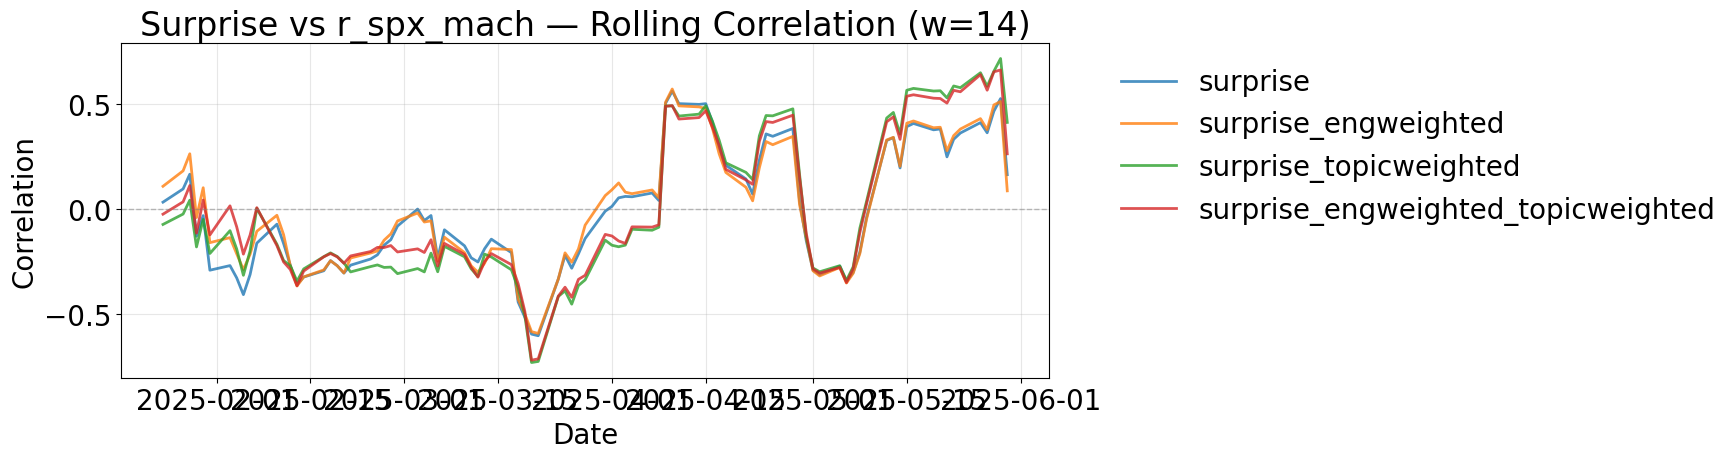

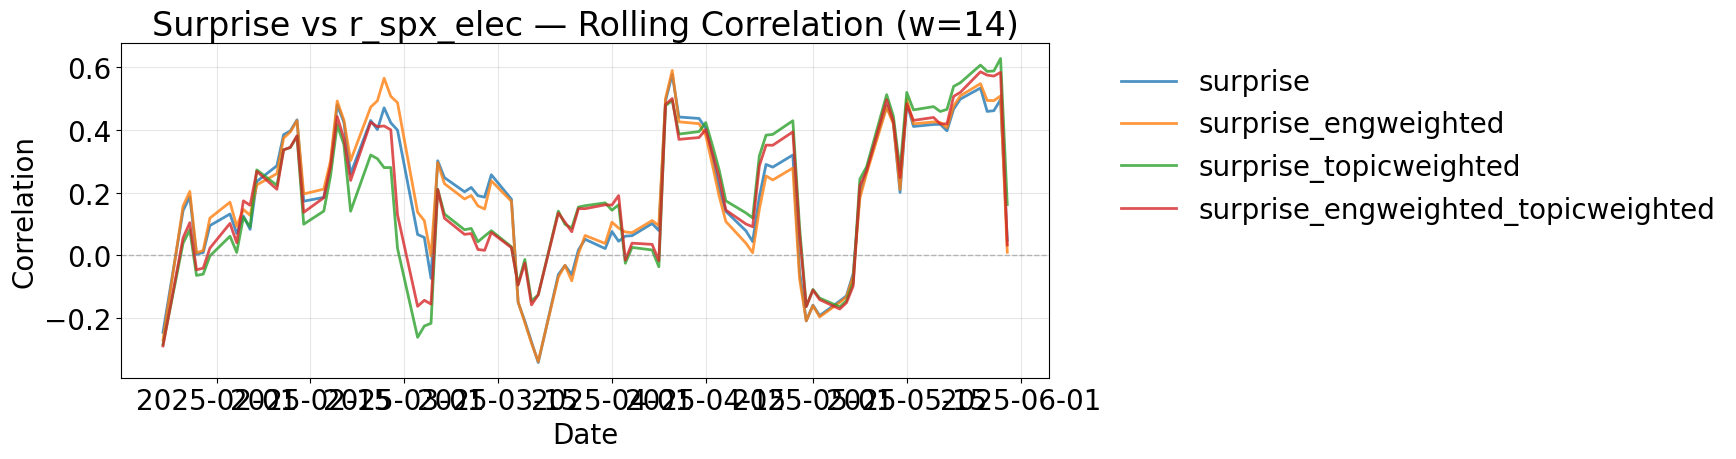

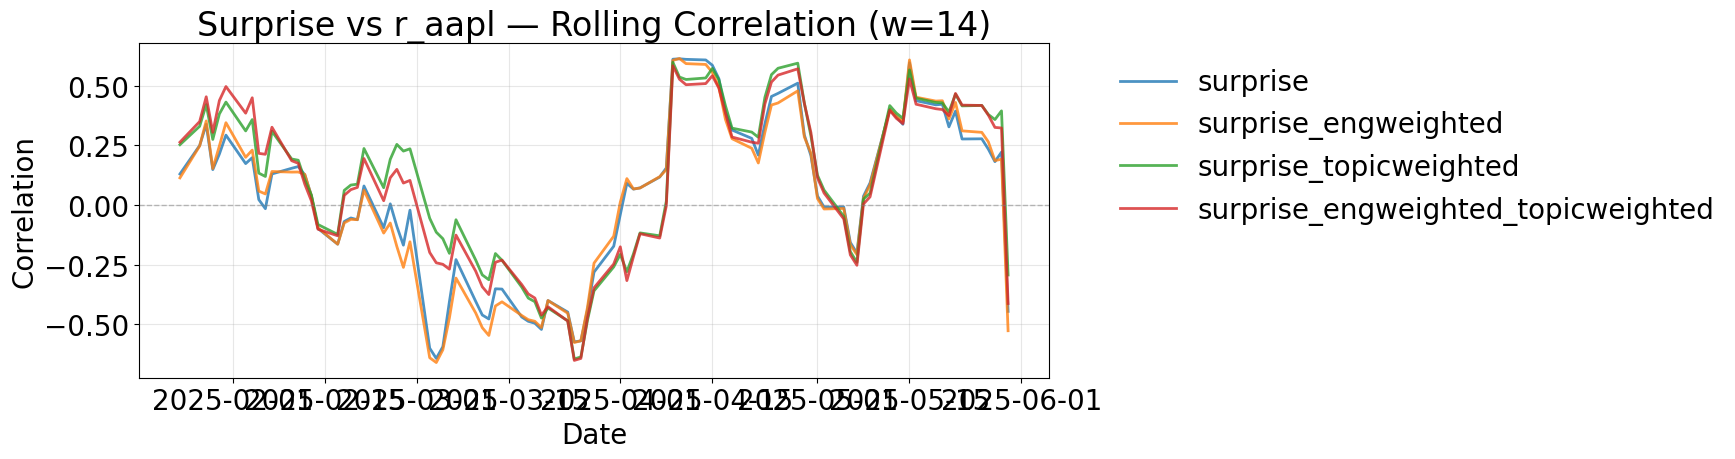

In [7]:
print("\n" + "="*70)
print("Rolling Correlations with Assets")
print("="*70)
compare_variants_vs_assets(df, surprise_variants, ASSET_COLS, 'Surprise', rolling_window=ROLLING_WINDOW)

## Granger Causality Tests

Test if Surprise variants Granger-cause asset returns using:
- AIC/BIC for optimal lag selection
- Benjamini-Hochberg FDR correction for multiple testing


Granger Causality Tests

GRANGER CAUSALITY TESTS: SURPRISE Variants
Running 32 Granger causality tests...
  Index → Asset causality
  Max lag: 10, Max lead: 10, IC: AIC
  Multiple testing correction: fdr_bh

✓ Tests complete
  LAG tests - Significant relationships (corrected α=0.05): 0 of 32
  LAG tests - Uncorrected significant (α=0.05): 1
  LEAD tests - Significant relationships (corrected α=0.05): 0 of 32
  LEAD tests - Uncorrected significant (α=0.05): 0

LAG RESULTS: X(t-k) → Y(t)

P-values (at optimal lag):


asset,r_aapl,r_btc,r_gold,r_spx,r_spx_auto,r_spx_elec,r_spx_mach,r_spx_oilgas
index,,,,,,,,
surprise,0.981549,0.923613,0.037771,0.756989,0.728895,0.876550,0.937589,0.366627
surprise_engweighted,0.938222,0.998313,0.051113,0.899002,0.807074,0.761251,0.887449,0.404211
surprise_engweighted_topicweighted,0.593296,0.636085,0.076355,0.383370,0.814140,0.441312,0.414365,0.179911
surprise_topicweighted,0.564513,0.537125,0.070009,0.334210,0.779419,0.417481,0.368662,0.172521



Corrected p-values (fdr_bh):


asset,r_aapl,r_btc,r_gold,r_spx,r_spx_auto,r_spx_elec,r_spx_mach,r_spx_oilgas
index,,,,,,,,
surprise,0.998313,0.998313,0.610841,0.998313,0.998313,0.998313,0.998313,0.998313
surprise_engweighted,0.998313,0.998313,0.610841,0.998313,0.998313,0.998313,0.998313,0.998313
surprise_engweighted_topicweighted,0.998313,0.998313,0.610841,0.998313,0.998313,0.998313,0.998313,0.959525
surprise_topicweighted,0.998313,0.998313,0.610841,0.998313,0.998313,0.998313,0.998313,0.959525



Significant relationships (α=0.05, corrected):


...

asset,r_aapl,r_btc,r_gold,r_spx,r_spx_auto,r_spx_elec,r_spx_mach,r_spx_oilgas
index,,,,,,,,
surprise,0.605314,0.238275,0.996334,0.891111,0.730727,0.333414,0.413456,0.496253
surprise_engweighted,0.643382,0.211968,0.975943,0.872860,0.722914,0.314811,0.392504,0.473819
surprise_engweighted_topicweighted,0.926327,0.438816,0.499580,0.372413,0.875390,0.536694,0.886470,0.715538
surprise_topicweighted,0.880358,0.442368,0.462712,0.310036,0.921964,0.700179,0.995661,0.684595



Corrected p-values (fdr_bh):


asset,r_aapl,r_btc,r_gold,r_spx,r_spx_auto,r_spx_elec,r_spx_mach,r_spx_oilgas
index,,,,,,,,
surprise,0.996334,0.996334,0.996334,0.996334,0.996334,0.996334,0.996334,0.996334
surprise_engweighted,0.996334,0.996334,0.996334,0.996334,0.996334,0.996334,0.996334,0.996334
surprise_engweighted_topicweighted,0.996334,0.996334,0.996334,0.996334,0.996334,0.996334,0.996334,0.996334
surprise_topicweighted,0.996334,0.996334,0.996334,0.996334,0.996334,0.996334,0.996334,0.996334



Significant relationships (α=0.05, corrected):


asset,r_aapl,r_btc,r_gold,r_spx,r_spx_auto,r_spx_elec,r_spx_mach,r_spx_oilgas
index,,,,,,,,
surprise,0,0,0,0,0,0,0,0
surprise_engweighted,0,0,0,0,0,0,0,0
surprise_engweighted_topicweighted,0,0,0,0,0,0,0,0
surprise_topicweighted,0,0,0,0,0,0,0,0


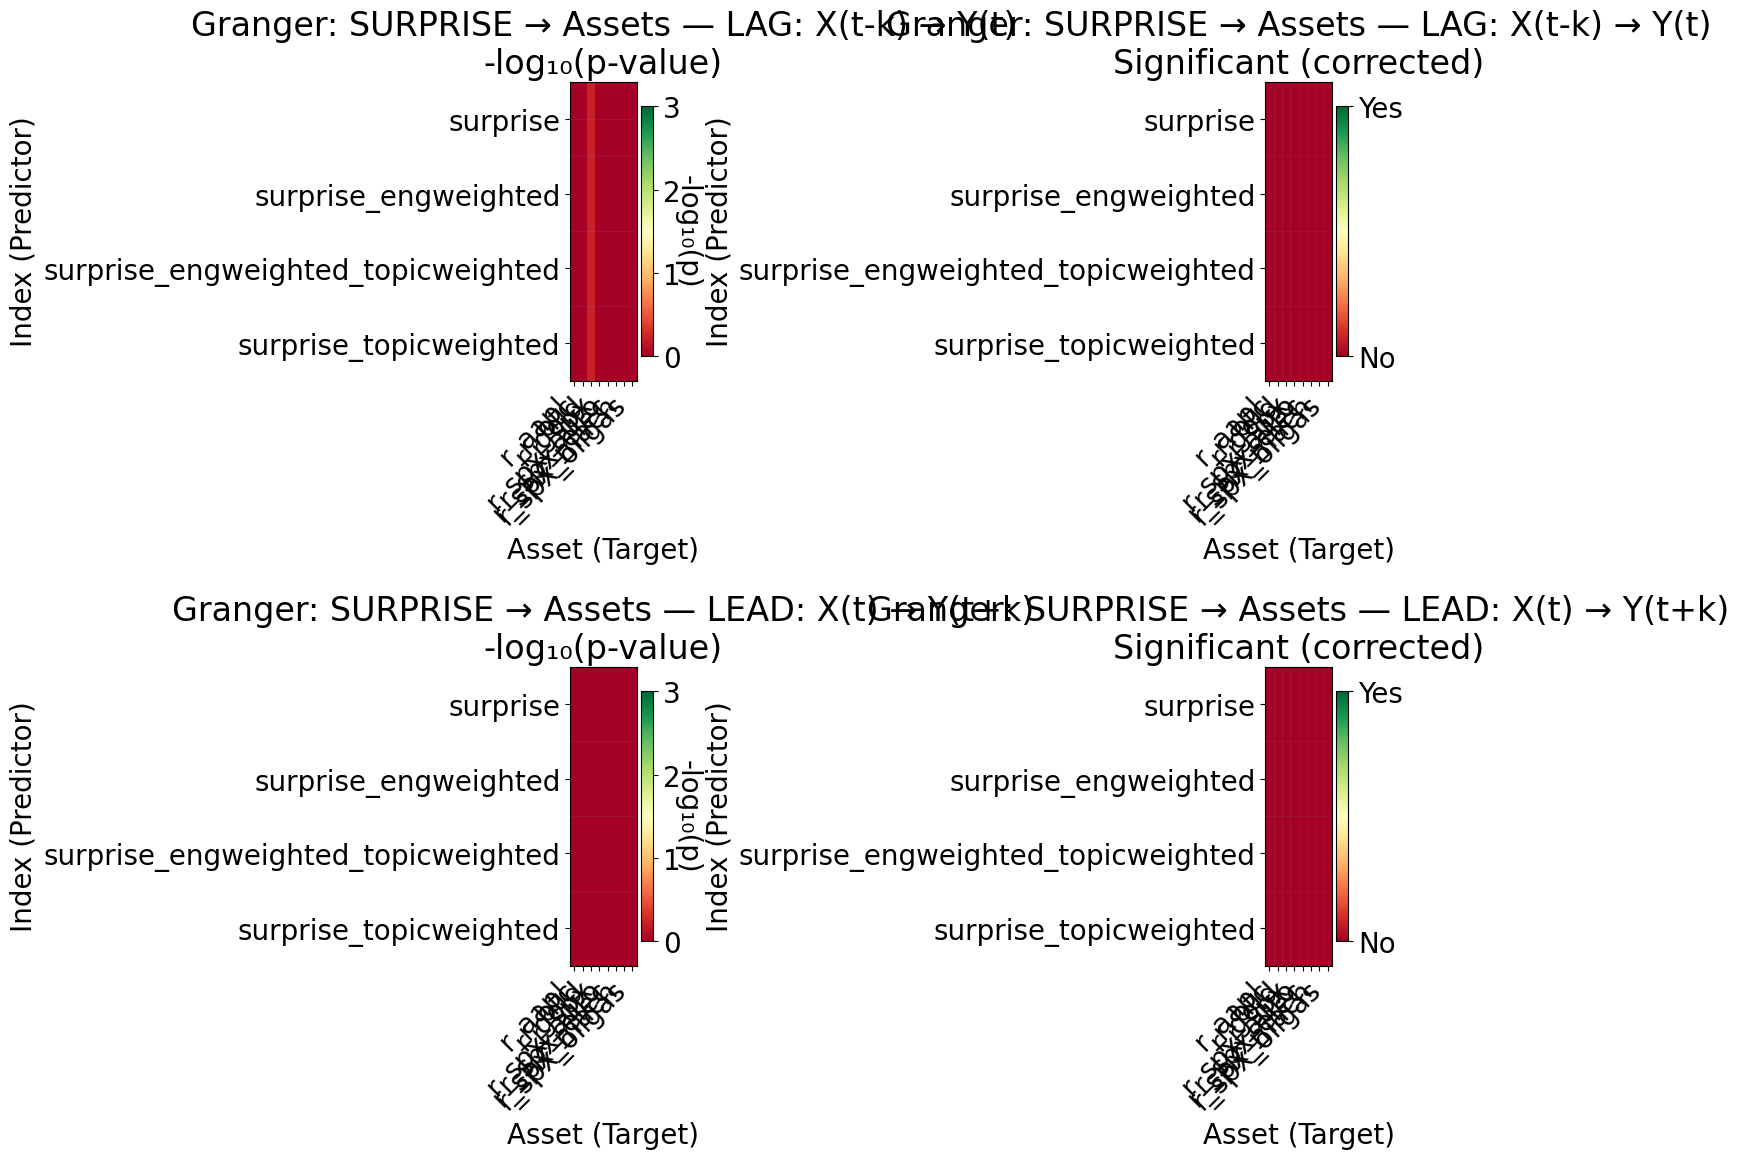

In [8]:
print("\n" + "="*70)
print("Granger Causality Tests")
print("="*70)

(pval_mat, pval_corrected, sig_mat, 
 lead_pval_mat, lead_pval_corrected, lead_sig_mat) = granger_comparison_variants(
    df, surprise_variants, ASSET_COLS,
    maxlag=MAX_LAG, ic=IC, alpha=ALPHA, correction_method=CORRECTION_METHOD
)

In [9]:
# Variant performance summary
print("\n" + "="*70)
print("Performance Summary")
print("="*70)
performance = summarize_variant_performance(
    pval_mat, sig_mat, 
    lead_pval_mat, lead_sig_mat, 
    surprise_variants
)


Performance Summary

VARIANT PERFORMANCE SUMMARY


,variant,n_significant_lags,mean_pvalue_lags,min_pvalue_lags,n_significant_leads,mean_pvalue_leads,min_pvalue_leads,total_significant
0,surprise,0,0.701198,0.037771,0,0.588111,0.238275,0
1,surprise_engweighted,0,0.718329,0.051113,0,0.576025,0.211968,0
2,surprise_topicweighted,0,0.405493,0.070009,0,0.674734,0.310036,0
3,surprise_engweighted_topicweighted,0,0.442354,0.076355,0,0.656403,0.372413,0


In [10]:
# Save results
pval_mat.to_csv(os.path.join(OUTPUT_DIR, "surprise_granger_pvalues.csv"))
pval_corrected.to_csv(os.path.join(OUTPUT_DIR, "surprise_granger_pvalues_corrected.csv"))
sig_mat.to_csv(os.path.join(OUTPUT_DIR, "surprise_granger_significant.csv"))
performance.to_csv(os.path.join(OUTPUT_DIR, "surprise_variant_performance.csv"), index=False)

print("\n✓ Results saved to:", OUTPUT_DIR)


✓ Results saved to: ./data/fm_prelim/


## Stationarity Tests

Check if series are stationary (required for valid Granger tests)

In [11]:
print("\n" + "="*70)
print("Stationarity Tests (ADF & KPSS)")
print("="*70)

stationarity_results = []

for var in surprise_variants:
    if var in df.columns:
        adf = adf_test(df[var])
        kpss_result = kpss_test(df[var])
        
        stationarity_results.append({
            'index': var,
            'adf_stat': adf['statistic'],
            'adf_pval': adf['pvalue'],
            'adf_stationary': '✓' if adf['is_stationary'] else '✗',
            'kpss_stat': kpss_result['statistic'],
            'kpss_pval': kpss_result['pvalue'],
            'kpss_stationary': '✓' if kpss_result['is_stationary'] else '✗'
        })

stationarity_df = pd.DataFrame(stationarity_results)
display(stationarity_df)

print("\nInterpretation:")
print("  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)")
print("  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)")


Stationarity Tests (ADF & KPSS)


,index,adf_stat,adf_pval,adf_stationary,kpss_stat,kpss_pval,kpss_stationary
0,surprise,-2.219243,0.199336,✗,0.620974,0.020730,✗
1,surprise_engweighted,-2.399900,0.141765,✗,0.679292,0.015428,✗
2,surprise_topicweighted,-2.407043,0.139759,✗,0.634979,0.019456,✗
3,surprise_engweighted_topicweighted,-2.517612,0.111248,✗,0.695192,0.013983,✗



Interpretation:
  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)
  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)


## Bidirectional Granger Tests

Test causality in both directions for best performing variant

In [12]:
print("\n" + "="*70)
print("TEST 7: Bidirectional Granger Tests")
print("="*70)

# Use best performing variant
best_variant = performance.iloc[0]['variant']
print(f"\nBest variant: {best_variant}\n")

bidirectional_results = []
for asset in ASSET_COLS:
    print(f"\n{best_variant} ↔ {asset}:")
    print("-" * 70)
    result = bidirectional_granger_test(df, best_variant, asset, maxlag=MAX_LAG, ic=IC, alpha=ALPHA)
    display(result)
    bidirectional_results.append(result)

# Save results
all_results = pd.concat(bidirectional_results, ignore_index=True)
all_results.to_csv(os.path.join(OUTPUT_DIR, "surprise_bidirectional_granger_tests.csv"), index=False)
print("\n✓ Bidirectional Granger test results saved to:", OUTPUT_DIR)


TEST 7: Bidirectional Granger Tests

Best variant: surprise


surprise ↔ r_btc:
----------------------------------------------------------------------


,direction,type,optimal_order,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,surprise → r_btc,lag,1,0.923613,0.091009,False,False
1,surprise → r_btc,lead,1,0.238275,0.077455,False,False
2,r_btc → surprise,lag,1,0.227849,0.007743,True,False
3,r_btc → surprise,lead,1,0.170480,0.033878,True,False



surprise ↔ r_gold:
----------------------------------------------------------------------


,direction,type,optimal_order,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,surprise → r_gold,lag,1,0.037771,0.035606,True,True
1,surprise → r_gold,lead,1,0.996334,0.001981,True,False
2,r_gold → surprise,lag,1,0.071747,0.071747,False,False
3,r_gold → surprise,lead,1,0.143752,0.020788,True,False



surprise ↔ r_spx:
----------------------------------------------------------------------


...


surprise ↔ r_spx_elec:
----------------------------------------------------------------------


,direction,type,optimal_order,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,surprise → r_spx_elec,lag,1,0.876550,0.224025,False,False
1,surprise → r_spx_elec,lead,1,0.333414,0.047796,True,False
2,r_spx_elec → surprise,lag,1,0.086946,0.000180,True,False
3,r_spx_elec → surprise,lead,3,0.000383,0.000383,True,True



surprise ↔ r_aapl:
----------------------------------------------------------------------


,direction,type,optimal_order,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,surprise → r_aapl,lag,1,0.981549,0.323343,False,False
1,surprise → r_aapl,lead,1,0.605314,0.225259,False,False
2,r_aapl → surprise,lag,1,0.030770,0.000155,True,True
3,r_aapl → surprise,lead,3,0.000443,0.000443,True,True



✓ Bidirectional Granger test results saved to: ./data/fm_prelim/


## Event Window Analysis

How do Surprise variants behave during major tariff events?

In [13]:
EVENT_WINDOWS = [
    ("Initial Tariff Announcements", "2025-01-20", "2025-01-26"),
    ("Tariffs Postponed", "2025-03-04", "2025-03-06"),
    ("China Retaliation & US Tariffs", "2025-03-10", "2025-03-13"),
    ("Global Tariffs", "2025-04-02", "2025-04-06"),
    ("US-China Tariff Threats", "2025-04-09", "2025-04-12"),
    ("Tariffs Relaxed", "2025-04-27", "2025-05-04"),
    ("Trade Deals", "2025-05-05", "2025-05-14"),
    ("Apple Tariff Threat", "2025-05-20", "2025-05-25"),
]

print("\n" + "="*70)
print("Event Window Analysis")
print("="*70)

event_comparison = event_window_comparison(df, surprise_variants, EVENT_WINDOWS, pre_days=7, post_days=7)

# Display delta rows only (more compact)
delta_rows = event_comparison[event_comparison['phase'].str.contains('Δ', na=False)]
display(delta_rows)

# Save
event_comparison.to_csv(os.path.join(OUTPUT_DIR, "surprise_event_windows.csv"), index=False)
print("\n✓ Event analysis saved")


Event Window Analysis


,event,phase,n,surprise_mean,surprise_std,surprise_engweighted_mean,surprise_engweighted_std,surprise_topicweighted_mean,surprise_topicweighted_std,surprise_engweighted_topicweighted_mean,surprise_engweighted_topicweighted_std
3,Initial Tariff Announcements,Δ during-pre,NaN,0.001384,NaN,0.000007,NaN,0.005451,NaN,0.003166,NaN
4,Initial Tariff Announcements,Δ post-during,NaN,0.001061,NaN,0.001399,NaN,-0.000267,NaN,0.000957,NaN
8,Tariffs Postponed,Δ during-pre,NaN,0.005522,NaN,0.005084,NaN,0.006201,NaN,0.006418,NaN
9,Tariffs Postponed,Δ post-during,NaN,-0.002329,NaN,-0.002165,NaN,-0.001490,NaN,-0.001165,NaN
13,China Retaliation & US Tariffs,Δ during-pre,NaN,-0.003508,NaN,-0.003510,NaN,-0.002903,NaN,-0.002776,NaN
14,China Retaliation & US Tariffs,Δ post-during,NaN,0.008624,NaN,0.008267,NaN,0.009156,NaN,0.008629,NaN
18,Global Tariffs,Δ during-pre,NaN,0.002423,NaN,0.003623,NaN,0.007013,NaN,0.009685,NaN
19,Global Tariffs,Δ post-during,NaN,0.023740,NaN,0.022001,NaN,0.027895,NaN,0.025139,NaN
23,US-China Tariff Threats,Δ during-pre,NaN,0.029620,NaN,0.028455,NaN,0.037529,NaN,0.036721,NaN
24,US-China Tariff Threats,Δ post-during,NaN,-0.013950,NaN,-0.013163,NaN,-0.025291,NaN,-0.024622,NaN



✓ Event analysis saved


## Summary

Comprehensive comparison of Surprise variants

In [14]:
print("\n" + "="*70)
print("SURPRISE VARIANT COMPARISON - SUMMARY")
print("="*70)

print("\n1. VARIANTS TESTED:")
for i, var in enumerate(surprise_variants, 1):
    print(f"   {i}. {var}")

print("\n2. CORRELATION WITH ASSETS (mean absolute):")
for var in surprise_variants:
    if var in df.columns:
        mean_abs_corr = df[[var] + ASSET_COLS].corr().loc[var, ASSET_COLS].abs().mean()
        print(f"   {var:40s}: {mean_abs_corr:.4f}")

print("\n3. GRANGER CAUSALITY (significant relationships after FDR):")
for _, row in performance.iterrows():
    print(f"   {row['variant']:40s}: Lags: {int(row['n_significant_lags'])}, Leads: {int(row['n_significant_leads'])}, Total: {int(row['total_significant'])}")

print("\n4. BEST PERFORMING VARIANT:")
print(f"   {best_variant}")
print(f"   - Significant Granger relationships (lags): {int(performance.iloc[0]['n_significant_lags'])}/{len(ASSET_COLS)}")
print(f"   - Significant Granger relationships (leads): {int(performance.iloc[0]['n_significant_leads'])}/{len(ASSET_COLS)}")
print(f"   - Mean p-value (lags): {performance.iloc[0]['mean_pvalue_lags']:.4f}")

print("\n5. BIDIRECTIONAL CAUSALITY ANALYSIS:")
print(f"   Testing: {best_variant} ↔ Assets")
bidirectional_summary = []
for asset in ASSET_COLS:
    result = bidirectional_granger_test(df, best_variant, asset, maxlag=MAX_LAG, ic=IC, alpha=ALPHA)
    
    # Extract significance for lag tests (predictive relationships)
    idx_to_asset_sig = result.loc[(result['direction'] == f'{best_variant} → {asset}') & 
                                   (result['type'] == 'lag'), 'granger_causes'].values[0]
    asset_to_idx_sig = result.loc[(result['direction'] == f'{asset} → {best_variant}') & 
                                   (result['type'] == 'lag'), 'granger_causes'].values[0]
    
    if idx_to_asset_sig and asset_to_idx_sig:
        relationship = "Bidirectional ↔"
    elif idx_to_asset_sig:
        relationship = "Index predicts →"
    elif asset_to_idx_sig:
        relationship = "Index reacts ←"
    else:
        relationship = "No causality ✗"
    
    print(f"   {asset:15s}: {relationship}")
    bidirectional_summary.append({
        'asset': asset,
        'index_predicts': idx_to_asset_sig,
        'index_reacts': asset_to_idx_sig,
        'relationship': relationship
    })

# Summary statistics
bidir_df = pd.DataFrame(bidirectional_summary)
n_predictive = bidir_df['index_predicts'].sum()
n_reactive = bidir_df['index_reacts'].sum()
n_bidirectional = (bidir_df['index_predicts'] & bidir_df['index_reacts']).sum()
n_unidirectional_predict = (bidir_df['index_predicts'] & ~bidir_df['index_reacts']).sum()
n_unidirectional_react = (~bidir_df['index_predicts'] & bidir_df['index_reacts']).sum()

print(f"\n   Summary:")
print(f"   - Predictive relationships (Index → asset): {n_predictive}/{len(ASSET_COLS)}")
print(f"   - Reactive relationships (asset → Index): {n_reactive}/{len(ASSET_COLS)}")
print(f"   - Bidirectional: {n_bidirectional}, Unidirectional predict: {n_unidirectional_predict}, Unidirectional react: {n_unidirectional_react}")

print("\n6. KEY INSIGHTS:")
print(f"   - Surprise captures unexpected emotional shifts")
print(f"   - High surprise may indicate new information arrival")
print(f"   - Potentially useful for predicting volatility rather than returns")
print(f"   - Lead tests help identify predictive vs reactive relationships")

print("\n" + "="*70)
print("✓ SURPRISE ANALYSIS COMPLETE")
print("="*70)


SURPRISE VARIANT COMPARISON - SUMMARY

1. VARIANTS TESTED:
   1. surprise
   2. surprise_engweighted
   3. surprise_topicweighted
   4. surprise_engweighted_topicweighted

2. CORRELATION WITH ASSETS (mean absolute):
   surprise                                : 0.2525
   surprise_engweighted                    : 0.2403
   surprise_topicweighted                  : 0.2833
   surprise_engweighted_topicweighted      : 0.2716

3. GRANGER CAUSALITY (significant relationships after FDR):
   surprise                                : Lags: 0, Leads: 0, Total: 0
   surprise_engweighted                    : Lags: 0, Leads: 0, Total: 0
   surprise_topicweighted                  : Lags: 0, Leads: 0, Total: 0
   surprise_engweighted_topicweighted      : Lags: 0, Leads: 0, Total: 0

4. BEST PERFORMING VARIANT:
   surprise
   - Significant Granger relationships (lags): 0/8
   - Significant Granger relationships (leads): 0/8
   - Mean p-value (lags): 0.7012

5. BIDIRECTIONAL CAUSALITY ANALYSIS:
   Test